In [1]:
import utils
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import traceback
import numpy as np
import cartopy.feature as cfeature

In [2]:
## Generating a random subset of frames to test centering on

random_links = utils.random_link_selection(10, 'Model_Data\links\link_list.txt')

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
C:\Users\12ian\AppData\Local\Temp\ipykernel_18268\3957799093.py:3: SyntaxWarning: invalid escape sequence '\l'
  random_links = utils.random_link_selection(10, 'Model_Data\links\link_list.txt')


Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


1002.1400146484375mb is below the pressure threshold of 1005mb


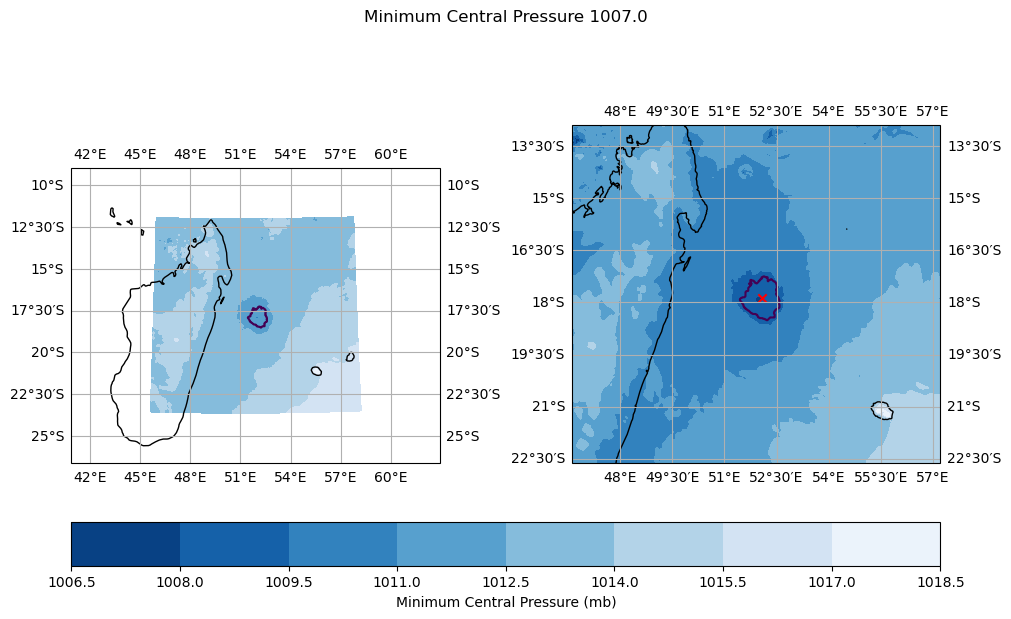

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


1006.010009765625mb is above the pressure threshold of 1005mb


Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


978.3900146484375mb is below the pressure threshold of 1005mb


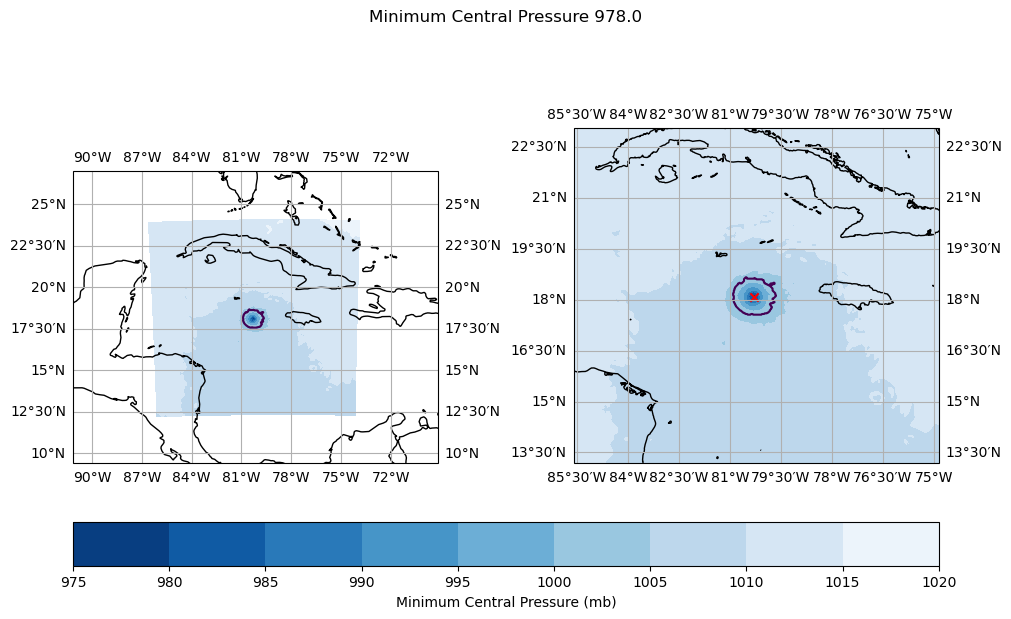

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


973.97998046875mb is below the pressure threshold of 1005mb


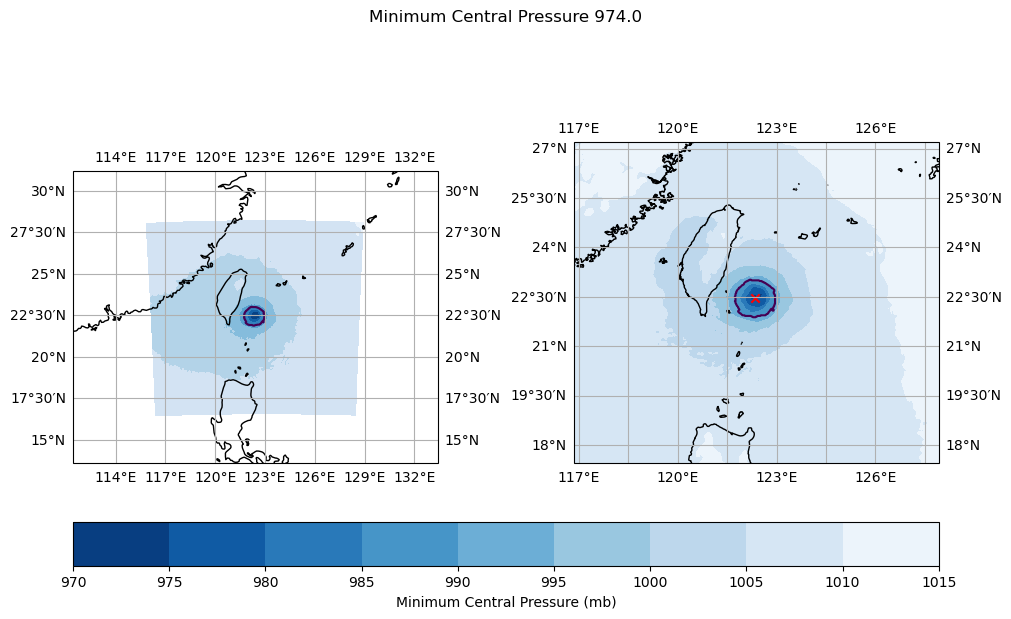

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


1000.6199951171875mb is below the pressure threshold of 1005mb


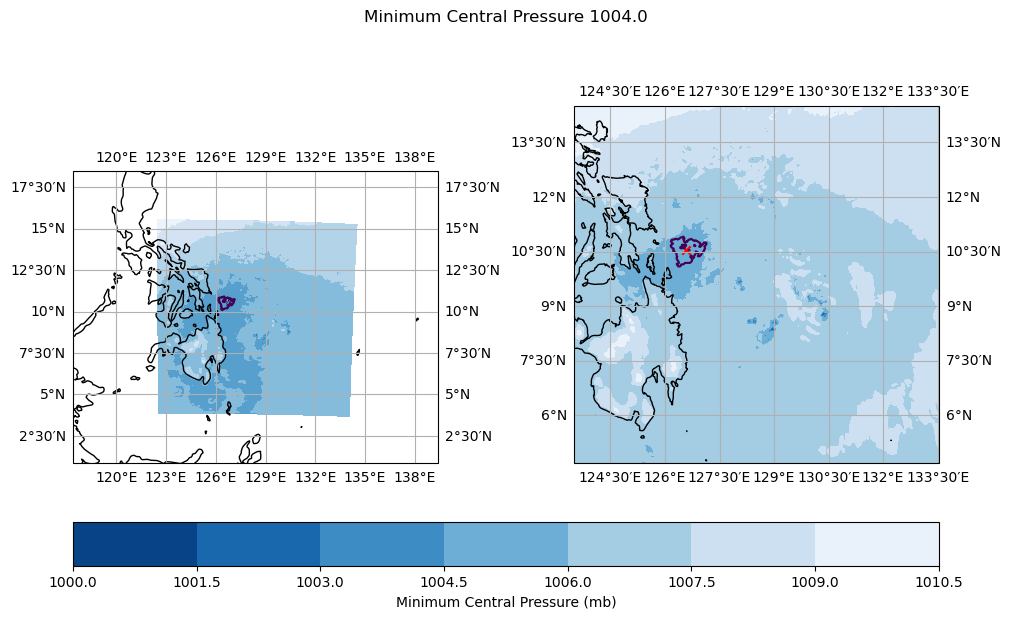

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


980.25mb is below the pressure threshold of 1005mb


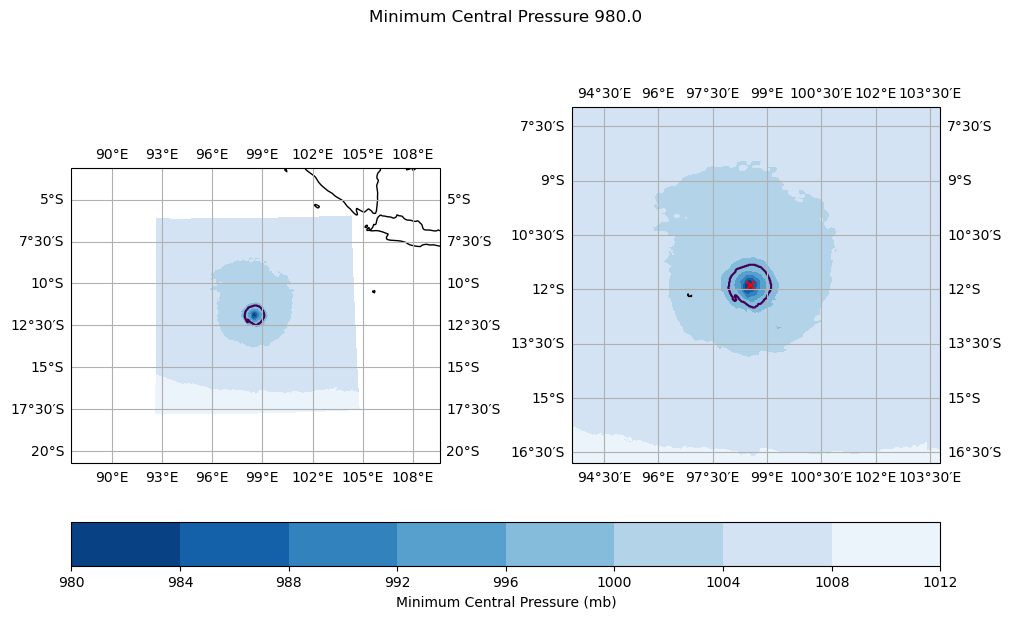

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


975.469970703125mb is below the pressure threshold of 1005mb


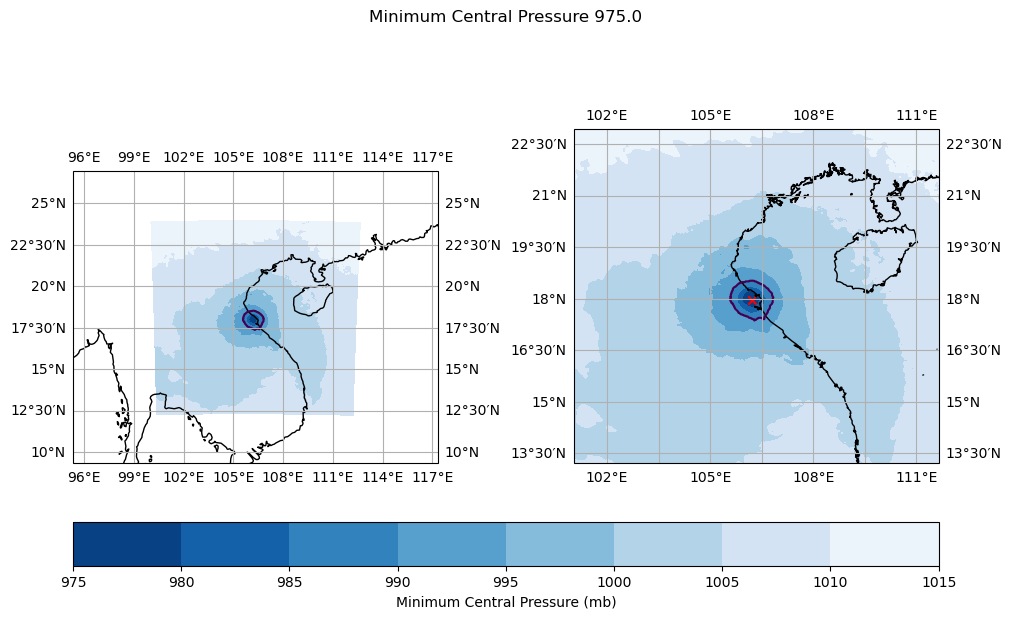

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


1007.2899780273438mb is above the pressure threshold of 1005mb


Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


1000.7100219726562mb is below the pressure threshold of 1005mb


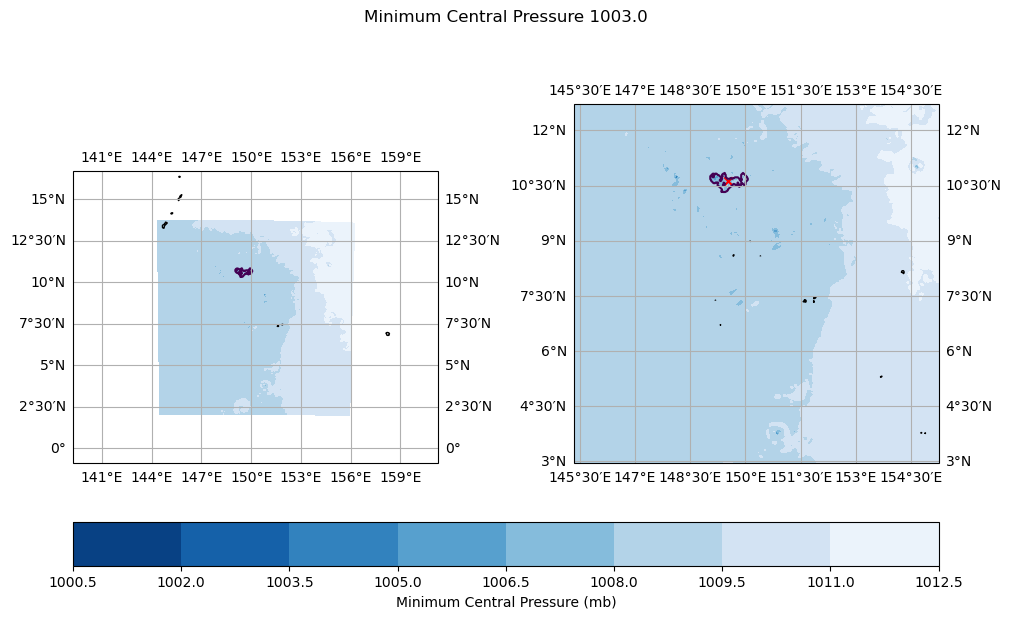

Ignoring index file 'temp.grib2.5b7b6.idx' older than GRIB file


1010.6699829101562mb is above the pressure threshold of 1005mb


In [3]:
fig_list = []

for link in random_links:

    sfc_ds = utils.download_and_open(url = link[0], typeOfKey = 'meanSea')
    try:
        center_info, center_cluster, lat_nest, lon_nest = utils.get_sfc_center(sfc_ds)
        if not center_info:
            continue
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,8), layout="constrained", subplot_kw = dict(projection = ccrs.PlateCarree()))
        ax[1].contour(lon_nest, lat_nest, center_cluster)
        zoomed_in_cf = ax[1].contourf(lon_nest, lat_nest, sfc_ds['prmsl'].sel(latitude = lat_nest, longitude = lon_nest).values, cmap = 'Blues_r')
        ax[1].scatter(center_info['center_lon'], center_info['center_lat'], color = 'red', marker = 'x')
        ax[1].add_feature(cfeature.COASTLINE)
        ax[1].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

        ax[0].contourf(sfc_ds.longitude.values, sfc_ds.latitude.values, sfc_ds['prmsl'].values,  cmap = 'Blues_r')
        ax[0].contour(lon_nest, lat_nest, center_cluster)
        ax[0].add_feature(cfeature.COASTLINE)
        ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)


        fig.colorbar(zoomed_in_cf, location = 'bottom', ax=[ax[0], ax[1]], label = 'Minimum Central Pressure (mb)')
        rounded_mslp = np.round(center_info['mslp'],decimals=0)
        fig.suptitle(f'Minimum Central Pressure {rounded_mslp}',y=0.75)

        plt.show()
    except Exception as e:
        print(e)
        traceback.print_exc()
    
    


In [ ]:
ds_sfc['prmsl'].shape